## Generation of random number using pseudo random and chi sq test

OBJECTIVE

To generate random numbers using a pseudo-random number generation method.
To test whether the generated numbers are uniformly distributed using the Chi-Square test.

THEORY

Random Number

A random number is a number selected without any predictable pattern. Each number has an equal chance of occurring. In computers, random numbers are usually generated using mathematical algorithms and are called pseudo-random numbers.

Random Variable

A random variable is a variable whose value depends on the outcome of a random experiment. It assigns numerical values to possible outcomes.

Example:

Tossing a coin:
Head = 1
Tail = 0

Thus, the random variable can take values 0 or 1.


Pseudo Random Number Generator (PRNG)

A Pseudo Random Number Generator (PRNG) is an algorithm used to generate a sequence of numbers that appears random. These numbers are not truly random because they are produced using a mathematical formula and an initial value called a seed.

One common PRNG method is the Linear Congruential Generator (LCG):

Xn+1=(aXn+c)modm



ALGORITHM

Algorithm 1: Linear Congruential Generator (LCG)

Choose values for:

Seed value X0

Multiplier a

Increment c

Modulus m

Generate the next random number using:Xn+1=(aXn+c)modm

Store the generated value Xn+1

Repeat Step 2 until the required number of random numbers is obtained.

Convert the generated values into the range (0,1) by dividing each value by m.

Algorithm 2: Mersenne Twister Generator

Initialize the generator with a seed value.

Create and fill the internal state array using the seed.

Generate a new state when all previous values are used.

Apply the twisting operation to improve randomness.

Apply tempering operations (bit shifts and XOR operations).

Output the generated random number.

Repeat Steps 3–6 until the required numbers are generated.


Algorithm 3: XOR Shift Generator

Choose an initial non-zero seed value x.

Apply XOR and shift operations:


x = x XOR (x << a)

x = x XOR (x >> b)

x = x XOR (x << c)


where a, b, and c are predefined shift values.

The resulting value of x is the next random number.

Store the generated number.

Repeat Step 2 for generating additional random numbers.


Values of r: [ 17  18  47 120 189 142  59 212  41 202   7 240  85 198 147 204  65 130
 223 104 237 254 235 196  89  58 183 224 133  54  67 188 113 242 143  88
  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72  77 222
  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78 251 148
 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132  25 250
 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106  39 144
 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128 165 214
  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70  19  76
 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60 241 114
  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226 191 200
 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184 253 206
 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62  43   4
 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244 201 234
 167  16 245 230  51 236 225 162 127 1

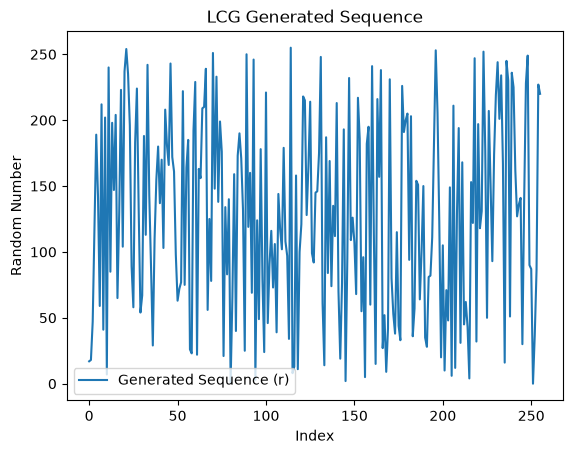

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
# Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) * 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi squsre test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()

Discussion

Random numbers were generated using a pseudo-random number generator.
The generated values were grouped into equal intervals.
The Chi-Square test was applied to compare observed and expected frequencies.
If the calculated Chi-Square value is smaller than the critical value from the Chi-Square table, the generated numbers can be considered uniformly distributed.
Small differences between observed and expected frequencies are normal because random numbers vary naturally.

Conclusion

Pseudo-random numbers were successfully generated using a computer algorithm. The Chi-Square test was performed to check the uniformity of the generated numbers. Based on the test result, it can be concluded that the generated numbers follow a nearly uniform distribution and can be used as random numbers for simulation and statistical applications.